# MambaLOB on FI-2010 + Efficiency Comparison (the novelty claim)

Trains **MambaLOB** (selective state-space model — this work's contribution) on FI-2010 and profiles
all four architectures for the efficiency story that motivates Mamba: **linear** vs the transformer's
**quadratic** scaling in sequence length.

What this notebook does:
1. Build `mamba-ssm` (CUDA) and confirm MambaLOB uses the fast kernel.
2. **E2** — MambaLOB variants on FI-2010:
   - **M1**: pure Mamba (no feature attention).
   - **M2**: Mamba (temporal) + feature self-attention (hybrid) — isolates what Mamba replaces well.
   - **M3**: M1 at a **4× longer window (T=400)** at similar params — the capability transformers can't afford.
3. **Efficiency**: params, inference latency (batch=1, HFT framing), peak GPU memory for all 4 models.
4. **Headline figure**: peak-memory and latency **vs sequence length** for TLOB vs MambaLOB (quadratic vs linear).

> Needs a **GPU runtime**. Reuses the repo's `load_fi2010` / `build_model` / `train`. Run the
> FI-2010 reproduction notebook first if you want the baseline CSV for the side-by-side in cell 10.


## 1. Runtime check (GPU required — Mamba needs CUDA)

In [1]:
import torch, platform
print("Python:", platform.python_version(), "| Torch:", torch.__version__, "| CUDA:", torch.version.cuda)
assert torch.cuda.is_available(), "Enable a GPU runtime: Runtime > Change runtime type > GPU."
print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.13 | Torch: 2.10.0+cu128 | CUDA: 12.8
GPU: Tesla T4


## 2. Get the project code
Same as the reproduction notebook — reads the `GH_PAT` Colab secret to clone the private repo.

In [3]:
import sys, subprocess, pathlib

REPO_URL = "https://github.com/rajjoseph48/nse-lob-capstone.git"
REPO_DIR = "nse-lob-capstone"
def _get_secret(name):
    # Kaggle -> Colab -> env var (inline: runs pre-clone, before nbenv is importable)
    try:
        from kaggle_secrets import UserSecretsClient
        v = UserSecretsClient().get_secret(name)
        if v:
            return v
    except Exception:
        pass
    try:
        from google.colab import userdata
        v = userdata.get(name)
        if v:
            return v
    except Exception:
        pass
    import os
    return os.environ.get(name, "")

GITHUB_TOKEN = _get_secret("GH_PAT")

def add_modeling(base):
    base = pathlib.Path(base)
    for cand in (base / "modeling", base):
        if (cand / "models.py").exists():
            sys.path.insert(0, str(cand.resolve()))
            return str(cand.resolve())
    return None

path = None
for c in (".", REPO_DIR, "/kaggle/working/" + REPO_DIR, "/content/" + REPO_DIR):
    path = add_modeling(c)
    if path:
        break
if not path:
    url = REPO_URL.replace("https://", f"https://{GITHUB_TOKEN}@") if GITHUB_TOKEN else REPO_URL
    subprocess.run(["git", "clone", "--depth", "1", url], check=True)
    path = add_modeling(REPO_DIR)
print("modeling/ on sys.path:", path)

Cloning into 'nse-lob-capstone'...


modeling/ on sys.path: /kaggle/working/nse-lob-capstone/modeling


## 3. Install Mamba kernel + profiling deps

`mamba-ssm` + `causal-conv1d` compile CUDA extensions — this can take a few minutes. If the build
fails, MambaLOB still runs via the pure-PyTorch fallback (`use_cuda_mamba=False`) but is **much** slower;
for real numbers you want the kernel. `fvcore` is for best-effort FLOP counts.

In [5]:
import subprocess, sys
def pipq(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)
pipq("fvcore")
pipq("boto3")
pipq("ninja", "packaging", "setuptools", "wheel")   # build backends for the CUDA extensions
pipq("--no-build-isolation", "causal-conv1d")        # lets the build see the installed torch
pipq("--no-build-isolation", "mamba-ssm")
try:
    import mamba_ssm
    print("install step done | mamba-ssm", mamba_ssm.__version__)
except Exception as e:
    print("install step done | mamba-ssm NOT importable -> pure-PyTorch fallback:", repr(e))

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.7/327.7 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 53.6 MB/s eta 0:00:00
install step done | mamba-ssm 2.3.2.post1


## 4. Confirm the Mamba CUDA kernel is active

In [6]:
import torch
from models import build_model
from train import DEVICE
try:
    import mamba_ssm  # noqa
    print("mamba-ssm import OK")
except Exception as e:
    print("mamba-ssm NOT available -> pure-PyTorch fallback (slow):", repr(e))

# Building MambaLOB prints which backend it picked.
m = build_model("mambalob", seq_len=100, n_features=40).to(DEVICE)
out = m(torch.randn(2, 100, 40, device=DEVICE))
print("MambaLOB forward:", tuple(out.shape), "| params:", sum(p.numel() for p in m.parameters()))

Using device: cuda
mamba-ssm import OK
MambaLOB: using mamba-ssm CUDA kernel.
MambaLOB forward: (2, 3) | params: 68291


## 5. Get FI-2010 data
Same as the reproduction notebook. Set `DATA_DIR` if you already have it; else Kaggle
(`KAGGLE_USERNAME`/`KAGGLE_KEY` from Colab secrets).

In [7]:
import pathlib, zipfile

DATA_DIR = ""   # set this if the data already exists in the runtime

def find_zscore_dir(root):
    root = pathlib.Path(root)
    if (root / "NoAuction_Zscore_Training").exists():
        return root
    for p in root.rglob("*"):
        if p.is_dir() and p.name.lower() == "noauction_zscore_training":
            return p.parent
    for p in root.rglob("*"):
        if p.is_dir() and "zscore" in p.name.lower() and "noauction" in p.name.lower():
            return p
    return None

# reuse an existing download if present
for cand in ("/kaggle/input", "fi2010_data", "."):
    if not DATA_DIR:
        f = find_zscore_dir(cand)
        if f: DATA_DIR = str(f)
print("DATA_DIR (pre-Kaggle) =", DATA_DIR or "(empty — run the Kaggle cell)")

DATA_DIR (pre-Kaggle) = /kaggle/input/datasets/ulfricirons/fi-2010/BenchmarkDatasets/NoAuction/1.NoAuction_Zscore


**Kaggle download** (skip if `DATA_DIR` is set):

In [ ]:
KAGGLE_SLUG = "ulfricirons/fi-2010"
KAGGLE_USERNAME = ""
KAGGLE_KEY = ""
if not DATA_DIR:
    import os
    KAGGLE_USERNAME = KAGGLE_USERNAME or _get_secret("KAGGLE_USERNAME")
    KAGGLE_KEY = KAGGLE_KEY or _get_secret("KAGGLE_KEY")
    if KAGGLE_USERNAME and KAGGLE_KEY:
        os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
        os.environ["KAGGLE_KEY"] = KAGGLE_KEY
    elif not os.environ.get("KAGGLE_KEY"):
        from google.colab import files
        print("No KAGGLE_USERNAME/KAGGLE_KEY set — upload kaggle.json instead")
        files.upload()
        !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
    !pip -q install kaggle
    !kaggle datasets download -d {KAGGLE_SLUG} -p fi2010_data --unzip
    for z in list(pathlib.Path("fi2010_data").rglob("*.zip")):
        with zipfile.ZipFile(z) as zf: zf.extractall(z.parent)
    DATA_DIR = str(find_zscore_dir("fi2010_data") or "")
assert DATA_DIR, "FI-2010 not found. Set DATA_DIR manually."
print("DATA_DIR =", DATA_DIR)

## 6. Metrics helper

In [12]:
import numpy as np, torch
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             matthews_corrcoef, confusion_matrix)
from fi2010_dataset import make_loader
from train import DEVICE

CLASS_NAMES = ["Down", "Stat", "Up"]

def collect_preds(model, ds, batch_size=256):
    model = model.to(DEVICE).eval()
    loader = make_loader(ds, batch_size=batch_size, shuffle=False)
    preds, labels = [], []
    with torch.no_grad():
        for X, y in loader:
            preds.append(model(X.to(DEVICE)).argmax(1).cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(preds), np.concatenate(labels)

def full_metrics(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2], zero_division=0)
    return {"accuracy": float(accuracy_score(y_true, y_pred)),
            "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
            "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
            "mcc": float(matthews_corrcoef(y_true, y_pred)),
            "per_class": {CLASS_NAMES[i]: {"precision": float(p[i]), "recall": float(r[i]),
                                           "f1": float(f[i])} for i in range(3)},
            "confusion": confusion_matrix(y_true, y_pred, labels=[0, 1, 2]).tolist()}

## 7. MambaLOB variant runner
Variant-aware: passes `seq_len` / `spatial_heads` to `build_model`. Appends to its own CSV, resumable.

In [13]:
import time, json, pathlib, pandas as pd
from fi2010_dataset import load_fi2010
from models import build_model
from train import train, save_checkpoint

RESULTS_DIR = pathlib.Path("results"); RESULTS_DIR.mkdir(exist_ok=True)
CKPT_DIR = pathlib.Path("checkpoints/mamba"); CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = RESULTS_DIR / "mamba_fi2010.csv"

from nbenv import s3_client, s3_put, s3_pull   # cross-timeout resumability
S3_BUCKET, S3_PREFIX = "lob-capstone-data", "reproduction/mamba"
_s3 = s3_client()

def run_mamba(variant, horizon, seq_len=100, epochs=50, batch_size=128, lr=3e-4, **model_kw):
    tag = f"mambalob_{variant}_h{horizon}_L{seq_len}"
    print("=" * 70); print(" ", tag, f"| kw={model_kw} lr={lr}"); print("=" * 70)
    tr, vl, te = load_fi2010(DATA_DIR, fold=7, horizon=horizon, seq_len=seq_len)
    model = build_model("mambalob", seq_len=seq_len, n_features=40, **model_kw)
    n_params = sum(p.numel() for p in model.parameters())
    t0 = time.time()
    hist = train(model, tr, vl, epochs=epochs, batch_size=batch_size, lr=lr, verbose=True)
    elapsed = time.time() - t0
    y_pred, y_true = collect_preds(model, te)
    mt = full_metrics(y_true, y_pred)
    ckpt = CKPT_DIR / f"{tag}.pt"; save_checkpoint(model, str(ckpt))
    row = {"model": "mambalob", "variant": variant, "horizon": horizon, "seq_len": seq_len,
           "spatial_heads": model_kw.get("spatial_heads", 0), "n_params": n_params,
           "best_epoch": hist["best_epoch"], "epochs_run": len(hist["val_f1"]),
           "best_val_f1": round(max(hist["val_f1"]), 4),
           "test_accuracy": round(mt["accuracy"], 4), "test_macro_f1": round(mt["macro_f1"], 4),
           "test_weighted_f1": round(mt["weighted_f1"], 4), "test_mcc": round(mt["mcc"], 4),
           "train_time_s": round(elapsed, 1), "checkpoint": str(ckpt)}
    df = pd.read_csv(RESULTS_CSV) if RESULTS_CSV.exists() else pd.DataFrame()
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    df.to_csv(RESULTS_CSV, index=False)
    with open(RESULTS_DIR / f"{tag}_metrics.json", "w") as fjs:
        json.dump(mt, fjs, indent=2)
    for _p in (RESULTS_CSV, ckpt, RESULTS_DIR / f"{tag}_metrics.json"):
        s3_put(_s3, _p, S3_BUCKET, S3_PREFIX)   # push this run now (timeout-safe)
    print(f"  -> macro_f1={mt['macro_f1']:.4f}  weighted_f1={mt['weighted_f1']:.4f}  "
          f"acc={mt['accuracy']:.4f}  ({elapsed:.0f}s)")
    return row, mt

## 8. Run the Mamba experiments (E2)

M1 (pure) and M2 (hybrid) across horizons; M3 is the long-context showcase (T=400, k=10).
Resumable — completed `(variant, horizon, seq_len)` rows are skipped.

In [14]:
HORIZONS = [10, 20, 50, 100]
EPOCHS = 50
VARIANTS = {"M1": dict(spatial_heads=0), "M2": dict(spatial_heads=4)}  # pure vs hybrid

s3_pull(_s3, RESULTS_CSV, S3_BUCKET, S3_PREFIX)   # resume from prior sessions' progress
done = set()
if RESULTS_CSV.exists():
    _d = pd.read_csv(RESULTS_CSV)
    done = {(r.variant, int(r.horizon), int(r.seq_len)) for r in _d.itertuples()}

for v, kw in VARIANTS.items():
    for h in HORIZONS:
        if (v, h, 100) in done:
            print(f"skip {v} h{h} L100 (in CSV)"); continue
        run_mamba(v, h, seq_len=100, epochs=EPOCHS, **kw)

# M3 — long-context (linear-scaling capability): T=400, same params as M1
if ("M3", 10, 400) not in done:
    run_mamba("M3", 10, seq_len=400, epochs=EPOCHS, spatial_heads=0)

pd.read_csv(RESULTS_CSV)

  mambalob_M1_h10_L100 | kw={'spatial_heads': 0} lr=0.0003

Loading FI-2010 | fold=CF_7 | horizon=k10 | seq_len=100
  Train: Train_Dst_NoAuction_ZScore_CF_7.txt  (149×254750 on disk → 254750×149 after transpose)
  Test:  Test_Dst_NoAuction_ZScore_CF_7.txt  (149×55478 on disk → 55478×149 after transpose)
  Parsing text files (one-time, ~60s) ...
  Cache saved → .cache_cf7.npz (future loads will be ~1s)
  Splits → train: 229,176  val: 25,376  test: 55,379
    train labels: Down:19.9%  Stat:60.0%  Up:20.0%
    test  labels: Down:14.0%  Stat:73.3%  Up:12.7%
MambaLOB: using mamba-ssm CUDA kernel.
  epoch   1 | train_loss 0.9812 | val_loss 1.0257 | val_f1 0.5750 ← best
  epoch   5 | train_loss 0.8494 | val_loss 0.8906 | val_f1 0.6428
  epoch  10 | train_loss 0.7877 | val_loss 0.8403 | val_f1 0.6710
  epoch  20 | train_loss 0.7405 | val_loss 0.8055 | val_f1 0.6869
  epoch  25 | train_loss 0.7128 | val_loss 0.7963 | val_f1 0.6796
  epoch  30 | train_loss 78.7950 | val_loss 0.7836 | val_f1 0.69

,model,variant,horizon,seq_len,spatial_heads,n_params,best_epoch,epochs_run,best_val_f1,test_accuracy,test_macro_f1,test_weighted_f1,test_mcc,train_time_s,checkpoint
0,mambalob,M1,10,100,0,68291,35,45,0.7008,0.7846,0.6741,0.7917,0.5304,987.3,checkpoints/mamba/mambalob_M1_h10_L100.pt
1,mambalob,M1,20,100,0,68291,22,32,0.6295,0.7103,0.6142,0.7111,0.4375,702.1,checkpoints/mamba/mambalob_M1_h20_L100.pt
2,mambalob,M1,50,100,0,68291,24,34,0.6536,0.7266,0.6997,0.7279,0.5606,745.6,checkpoints/mamba/mambalob_M1_h50_L100.pt
3,mambalob,M1,100,100,0,68291,30,40,0.6448,0.6929,0.6874,0.6933,0.5363,878.0,checkpoints/mamba/mambalob_M1_h100_L100.pt
4,mambalob,M2,10,100,4,108891,15,25,0.7109,0.7845,0.6692,0.7901,0.5223,706.0,checkpoints/mamba/mambalob_M2_h10_L100.pt
5,mambalob,M2,20,100,4,108891,13,23,0.6109,0.7045,0.5962,0.7019,0.4149,649.2,checkpoints/mamba/mambalob_M2_h20_L100.pt
6,mambalob,M2,50,100,4,108891,11,21,0.6336,0.7207,0.6915,0.7196,0.5452,593.1,checkpoints/mamba/mambalob_M2_h50_L100.pt
7,mambalob,M2,100,100,4,108891,49,50,0.8403,0.7671,0.7662,0.7672,0.6483,1411.6,checkpoints/mamba/mambalob_M2_h100_L100.pt
8,mambalob,M3,10,400,0,68291,12,22,0.6711,0.7850,0.6661,0.7901,0.5179,1658.4,checkpoints/mamba/mambalob_M3_h10_L400.pt


## 9. Mamba vs baselines (FI-2010 macro-F1)
Pulls the reproduction CSV (`fi2010_reproduction.csv`) if present and stacks it next to Mamba.

In [15]:
import pandas as pd
mamba = pd.read_csv(RESULTS_CSV)
mamba_m1 = mamba[mamba.variant == "M1"][["horizon", "test_macro_f1"]].rename(columns={"test_macro_f1": "mambalob_M1"})
tbl = mamba_m1.set_index("horizon")
repro_path = RESULTS_DIR / "fi2010_reproduction.csv"
if repro_path.exists():
    rep = pd.read_csv(repro_path)
    piv = rep.pivot_table(index="horizon", columns="model", values="test_macro_f1")
    tbl = piv.join(tbl, how="outer")
print("FI-2010 macro-F1 by horizon:")
print(tbl.round(4).to_string())

FI-2010 macro-F1 by horizon:
         mambalob_M1
horizon             
10            0.6741
20            0.6142
50            0.6997
100           0.6874


## 10. Efficiency profiling (params · latency · peak memory)

Uses random input (no data needed). Latency at **batch=1** is the HFT-relevant figure. FLOPs are
best-effort via fvcore — Mamba's selective-scan is a custom op fvcore can't count, so treat its FLOPs
as a lower bound and lean on **latency + memory** as the honest efficiency evidence.

In [16]:
import torch, time, pandas as pd, pathlib
from models import build_model
from train import DEVICE

def profile_model(name, seq_len=100, n_features=40, batch=1, reps=50, **kw):
    m = build_model(name, seq_len=seq_len, n_features=n_features, **kw).to(DEVICE).eval()
    x = torch.randn(batch, seq_len, n_features, device=DEVICE)
    with torch.no_grad():
        for _ in range(10):
            m(x)  # warmup
    torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
    t0 = time.time()
    with torch.no_grad():
        for _ in range(reps):
            m(x)
    torch.cuda.synchronize()
    lat_ms = (time.time() - t0) / reps * 1000
    peak_mb = torch.cuda.max_memory_allocated() / 1e6
    flops = None
    try:
        from fvcore.nn import FlopCountAnalysis
        flops = FlopCountAnalysis(m, x).unsupported_ops_warnings(False).total() / 1e6  # MFLOPs
    except Exception:
        pass
    return {"model": name, "seq_len": seq_len, "batch": batch,
            "params": sum(p.numel() for p in m.parameters()),
            "latency_ms": round(lat_ms, 3), "peak_mb": round(peak_mb, 1),
            "MFLOPs": round(flops, 1) if flops else None}

rows = [profile_model(n, seq_len=100, batch=1) for n in ["deeplob", "mlplob", "tlob", "mambalob"]]
eff = pd.DataFrame(rows)
print(eff.to_string(index=False))
eff.to_csv(RESULTS_DIR / "efficiency_seq100.csv", index=False)

The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
net.layers.0.attention.out_proj, net.layers.1.attention.out_proj, net.layers.2.attention.out_proj, net.layers.3.attention.out_proj, net.layers.4.attention.out_proj, net.layers.5.attention.out_proj, net.layers.6.attention.out_proj, net.layers.7.attention.out_proj
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
mamba_layers.0.act, mamba_layers.0.conv1d, mamba_layers.0.dt_proj, mamba_layers.0.in_proj, ma

MambaLOB: using mamba-ssm CUDA kernel.
   model  seq_len  batch  params  latency_ms  peak_mb  MFLOPs
 deeplob      100      1  191351       1.511     30.3    19.6
  mlplob      100      1  529411       0.220     21.5     0.5
    tlob      100      1 1800348       6.126     27.3   167.1
mambalob      100      1   68291       1.453     20.0     3.5


## 11. Headline: memory & latency vs sequence length (TLOB vs MambaLOB)

The core novelty evidence — transformer attention is **O(L²)** in memory/compute, Mamba is **O(L)**.
We sweep the window length and plot peak memory and latency for both. TLOB may OOM at large L (that's
the point); those points are skipped and logged.

The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
net.layers.0.attention.out_proj, net.layers.1.attention.out_proj, net.layers.2.attention.out_proj, net.layers.3.attention.out_proj, net.layers.4.attention.out_proj, net.layers.5.attention.out_proj, net.layers.6.attention.out_proj, net.layers.7.attention.out_proj
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
mamba_layers.0.act, mamba_layers.0.conv1d, mamba_layers.0.dt_proj, mamba_layers.0.in_proj, ma

MambaLOB: using mamba-ssm CUDA kernel.


The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
net.layers.0.attention.out_proj, net.layers.1.attention.out_proj, net.layers.2.attention.out_proj, net.layers.3.attention.out_proj, net.layers.4.attention.out_proj, net.layers.5.attention.out_proj, net.layers.6.attention.out_proj, net.layers.7.attention.out_proj
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
mamba_layers.0.act, mamba_layers.0.conv1d, mamba_layers.0.dt_proj, mamba_layers.0.in_proj, ma

MambaLOB: using mamba-ssm CUDA kernel.


The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
net.layers.0.attention.out_proj, net.layers.1.attention.out_proj, net.layers.2.attention.out_proj, net.layers.3.attention.out_proj, net.layers.4.attention.out_proj, net.layers.5.attention.out_proj, net.layers.6.attention.out_proj, net.layers.7.attention.out_proj
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
mamba_layers.0.act, mamba_layers.0.conv1d, mamba_layers.0.dt_proj, mamba_layers.0.in_proj, ma

MambaLOB: using mamba-ssm CUDA kernel.


The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
net.layers.0.attention.out_proj, net.layers.1.attention.out_proj, net.layers.2.attention.out_proj, net.layers.3.attention.out_proj, net.layers.4.attention.out_proj, net.layers.5.attention.out_proj, net.layers.6.attention.out_proj, net.layers.7.attention.out_proj


MambaLOB: using mamba-ssm CUDA kernel.


The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
mamba_layers.0.act, mamba_layers.0.conv1d, mamba_layers.0.dt_proj, mamba_layers.0.in_proj, mamba_layers.0.out_proj, mamba_layers.0.x_proj, mamba_layers.1.act, mamba_layers.1.conv1d, mamba_layers.1.dt_proj, mamba_layers.1.in_proj, mamba_layers.1.out_proj, mamba_layers.1.x_proj


   model  seq_len  batch   params  latency_ms  peak_mb   MFLOPs
    tlob      100     32  1800348      10.849     49.4   5347.5
mambalob      100     32    68291       1.452     32.2    113.1
    tlob      200     32  4147523      19.908     80.0  14904.3
mambalob      200     32    68291       1.497     44.2    226.1
    tlob      400     32 13531473      53.954    164.0  46645.9
mambalob      400     32    68291       1.843     69.1    452.2
    tlob      800     32 51029773     163.628    400.4 160641.0
mambalob      800     32    68291       5.298    118.5    904.4


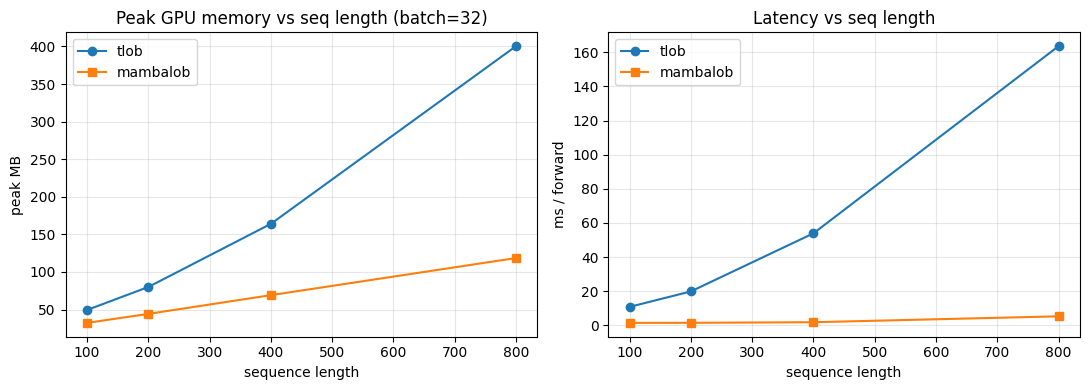

In [17]:
import matplotlib.pyplot as plt, pandas as pd

SEQ_LENS = [100, 200, 400, 800]
BATCH = 32
curve = []
for L in SEQ_LENS:
    for name in ["tlob", "mambalob"]:
        try:
            curve.append(profile_model(name, seq_len=L, batch=BATCH, reps=20))
        except RuntimeError as e:
            print(f"{name} L={L}: {str(e)[:70]}")
            torch.cuda.empty_cache()
cdf = pd.DataFrame(curve)
cdf.to_csv(RESULTS_DIR / "scaling_curve.csv", index=False)
print(cdf.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for name, mk in [("tlob", "o-"), ("mambalob", "s-")]:
    d = cdf[cdf.model == name].sort_values("seq_len")
    ax[0].plot(d.seq_len, d.peak_mb, mk, label=name)
    ax[1].plot(d.seq_len, d.latency_ms, mk, label=name)
ax[0].set(title=f"Peak GPU memory vs seq length (batch={BATCH})", xlabel="sequence length", ylabel="peak MB")
ax[1].set(title="Latency vs seq length", xlabel="sequence length", ylabel="ms / forward")
for a in ax: a.grid(True, alpha=0.3); a.legend()
plt.tight_layout(); plt.savefig(RESULTS_DIR / "fig_scaling_tlob_vs_mamba.png", dpi=150, bbox_inches="tight"); plt.show()

## 12. Persist results + figures (S3 / Drive)

In [18]:
import os, glob
S3_BUCKET, S3_PREFIX, S3_REGION = "lob-capstone-data", "reproduction/mamba", "ap-south-2"
for _k in ("AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY"):
    os.environ.setdefault(_k, _get_secret(_k))   # AWS creds from Kaggle/Colab secrets
try:
    import boto3
    s3 = boto3.client("s3", region_name=S3_REGION)
    for f in glob.glob("results/*") + glob.glob("checkpoints/mamba/*"):
        key = f"{S3_PREFIX}/{f}"; s3.upload_file(f, S3_BUCKET, key); print("uploaded", key)
    print(f"Done -> s3://{S3_BUCKET}/{S3_PREFIX}/")
except Exception as e:
    print("S3 upload skipped:", repr(e))
# Drive alternative:
# from google.colab import drive; drive.mount("/content/drive")
# import shutil; shutil.copytree("results", "/content/drive/MyDrive/mamba_fi2010/results", dirs_exist_ok=True)

uploaded reproduction/mamba/results/mambalob_M2_h20_L100_metrics.json
uploaded reproduction/mamba/results/mambalob_M1_h50_L100_metrics.json
uploaded reproduction/mamba/results/mambalob_M2_h50_L100_metrics.json
uploaded reproduction/mamba/results/fig_scaling_tlob_vs_mamba.png
uploaded reproduction/mamba/results/mambalob_M1_h10_L100_metrics.json
uploaded reproduction/mamba/results/mambalob_M1_h100_L100_metrics.json
uploaded reproduction/mamba/results/mambalob_M3_h10_L400_metrics.json
uploaded reproduction/mamba/results/efficiency_seq100.csv
uploaded reproduction/mamba/results/mamba_fi2010.csv
uploaded reproduction/mamba/results/mambalob_M2_h10_L100_metrics.json
uploaded reproduction/mamba/results/mambalob_M2_h100_L100_metrics.json
uploaded reproduction/mamba/results/mambalob_M1_h20_L100_metrics.json
uploaded reproduction/mamba/results/scaling_curve.csv
uploaded reproduction/mamba/checkpoints/mamba/mambalob_M1_h100_L100.pt
uploaded reproduction/mamba/checkpoints/mamba/mambalob_M1_h10_L100